In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
training = pd.read_csv('training_data.csv')
training

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,20.195270,0.194058,2.189912,1.0,1.0,0.0,1.0,0.0
1,22.727047,7.108207,0.408434,1.0,1.0,0.0,0.0,0.0
2,16.237526,3.978321,1.100528,1.0,0.0,0.0,1.0,0.0
3,2.191026,0.042539,4.816317,1.0,0.0,0.0,1.0,1.0
4,5.195099,1.100097,0.792691,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
899995,0.539606,3.479517,0.129496,0.0,0.0,0.0,0.0,0.0
899996,113.803098,0.165044,1.523632,1.0,0.0,0.0,0.0,0.0
899997,20.473521,0.004376,0.915167,1.0,0.0,0.0,0.0,0.0
899998,9.958865,0.168019,1.174115,1.0,0.0,0.0,1.0,0.0


In [4]:
testing = pd.read_csv('test_data.csv')
testing

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,0.929509,1.296477,0.361110,0.0,0.0,0.0,1.0,0.0
1,0.611179,0.208295,3.118884,0.0,0.0,0.0,1.0,0.0
2,3.956062,0.529194,1.579942,1.0,0.0,0.0,0.0,0.0
3,21.798902,0.019399,11.416909,1.0,0.0,0.0,0.0,0.0
4,3.310635,1.707802,2.028915,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
99995,5.196402,1.306204,1.133054,1.0,0.0,0.0,1.0,0.0
99996,56.279883,0.152974,0.277104,1.0,0.0,0.0,0.0,0.0
99997,28.424613,0.466520,1.577858,1.0,1.0,0.0,1.0,0.0
99998,26.574444,2.679191,1.471028,1.0,0.0,0.0,1.0,0.0


In [9]:
# defining X and y
X_train = training.drop(columns=['fraud'])
y_train = training['fraud']

X_test = testing.drop(columns=['fraud'])
y_test = testing['fraud']

# scaling features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# building pipeline for scaling
pipeline = Pipeline([('scaler', StandardScaler()),
                     ('model', LogisticRegression(
                         class_weight='balanced',
                         max_iter=1000))])

# defining model
log_reg = LogisticRegression(
    class_weight='balanced', # fraud is rare, so we need to balance data to treat as important
    max_iter=1000)

# fitting model
log_reg.fit(X_train_scaled, y_train)

# predicting
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# evaluations
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96     91297
         1.0       0.58      0.95      0.72      8703

    accuracy                           0.94    100000
   macro avg       0.79      0.94      0.84    100000
weighted avg       0.96      0.94      0.94    100000



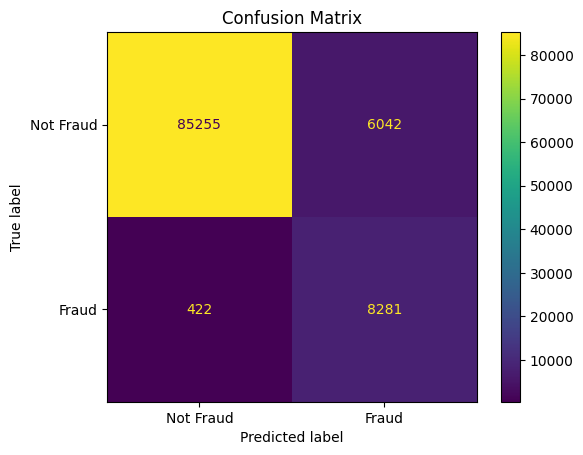

In [13]:
# plotting confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Fraud", "Fraud"])

plt.title("Confusion Matrix")
plt.show()

In [16]:
# seeing with L1 penatly
l1_log_reg = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000)

l1_log_reg.fit(X_train_scaled, y_train)

y_pred_l1 = l1_log_reg.predict(X_test_scaled)
y_prob_l1 = l1_log_reg.predict_proba(X_test_scaled)[:, 1]

print("L1 Logistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_l1))

L1 Logistic Regression Classification Report:

              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96     91297
         1.0       0.58      0.95      0.72      8703

    accuracy                           0.94    100000
   macro avg       0.79      0.94      0.84    100000
weighted avg       0.96      0.94      0.94    100000



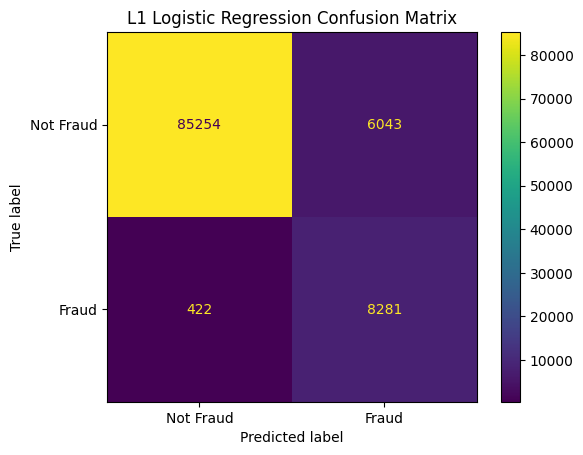

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_l1,
    display_labels=["Not Fraud", "Fraud"])

plt.title("L1 Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
# ok did nothing